In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

Objetivo do experimento
Contexto

Uma loja virtual internacional executou um teste A/B chamado:

recommender_system_test

O objetivo era avaliar se um novo sistema de recomendações melhora a conversão dos usuários no funil de compra.

O experimento foi conduzido com:

    Grupo A → controle (sistema atual)

    Grupo B → novo sistema de recomendações

A audiência do teste corresponde a 15% dos novos usuários da União Europeia.

O comportamento dos usuários foi observado durante 14 dias após o registro.

Hipótese do experimento

A empresa espera que o novo sistema melhore o funil de conversão em pelo menos 10% nas seguintes etapas:

    product_page → product_cart → purchase
    
Hipóteses estatísticas

Para cada etapa do funil:

    H0 (Hipótese nula)
    A taxa de conversão entre os grupos A e B é igual.

H1 (Hipótese alternativa)
A taxa de conversão do grupo B é maior que a do grupo A.


In [4]:
events = pd.read_csv('C:/Users/Depois vc troca/Desktop/Tripple Ten/projeto final/Teste AB/final_ab_events_upd_us.csv')
users = pd.read_csv('C:/Users/Depois vc troca/Desktop/Tripple Ten/projeto final/Teste AB/final_ab_new_users_upd_us_(1).csv')
participants = pd.read_csv('C:/Users/Depois vc troca/Desktop/Tripple Ten/projeto final/Teste AB/final_ab_participants_upd_us_(1).csv')
marketing = pd.read_csv('C:/Users/Depois vc troca/Desktop/Tripple Ten/projeto final/Teste AB/ab_project_marketing_events_us_(1).csv')

In [16]:
events.info()
print()
users.info()
print()
participants.info()
print()
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     423761 non-null  object        
 1   event_dt    423761 non-null  datetime64[ns]
 2   event_name  423761 non-null  object        
 3   details     60314 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 12.9+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     58703 non-null  object        
 1   first_date  58703 non-null  datetime64[ns]
 2   region      58703 non-null  object        
 3   device      58703 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 1.8+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 

In [5]:
events['event_dt'] = pd.to_datetime(events['event_dt'])
users['first_date'] = pd.to_datetime(users['first_date'])

In [11]:
events.isna().sum()


user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

In [12]:
users.isna().sum()


user_id       0
first_date    0
region        0
device        0
dtype: int64

In [13]:
participants.isna().sum()

user_id    0
group      0
ab_test    0
dtype: int64

In [17]:
events.duplicated().sum()

np.int64(0)

In [18]:
users.duplicated().sum()


np.int64(0)

In [19]:
participants.duplicated().sum()

np.int64(0)

In [20]:
df = events.merge(users, on='user_id', how='left')
df = df.merge(participants, on='user_id', how='left')

In [23]:
df = df[df['ab_test'] == 'recommender_system_test']
df = df[df['region'] == 'EU']
df = df[df['event_dt'] <= df['first_date'] + pd.Timedelta(days=14)]

ANÁLISE DO FUNIL DE CONVERSÃO

In [26]:
funnel_steps = ['login','product_page','product_cart','purchase']

funnel = (
    df[df['event_name'].isin(funnel_steps)]
    .groupby(['group','event_name'])['user_id']
    .nunique()
    .unstack()
    .reindex(columns=funnel_steps)
)

funnel

event_name,login,product_page,product_cart,purchase
group,,,,
A,2604,1685,782,833
B,876,493,244,249


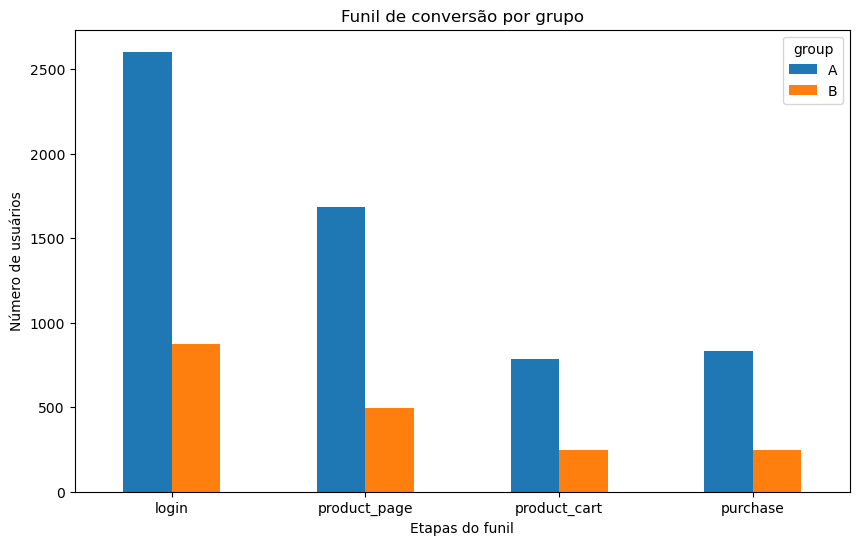

In [27]:
funnel.T.plot(kind='bar', figsize=(10,6))

plt.title('Funil de conversão por grupo')
plt.ylabel('Número de usuários')
plt.xlabel('Etapas do funil')
plt.xticks(rotation=0)

plt.show()

Observação:

A distribuição não está equilibrada.
O grupo B é significativamente menor, o que pode reduzir o poder estatístico do teste.

In [28]:
conversion_rates = funnel.copy()

conversion_rates['product_page_conversion'] = funnel['product_page'] / funnel['login']
conversion_rates['product_cart_conversion'] = funnel['product_cart'] / funnel['product_page']
conversion_rates['purchase_conversion'] = funnel['purchase'] / funnel['product_cart']

conversion_rates

event_name,login,product_page,product_cart,purchase,product_page_conversion,product_cart_conversion,purchase_conversion
group,,,,,,,
A,2604,1685,782,833,0.647081,0.464095,1.065217
B,876,493,244,249,0.562785,0.494929,1.020492


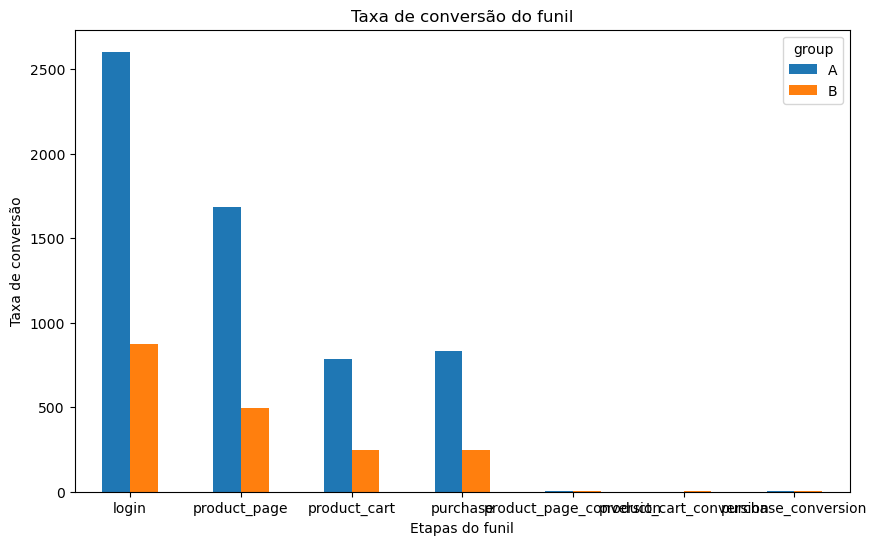

In [29]:
conversion_rates.T.plot(kind='bar', figsize=(10,6))

plt.title('Taxa de conversão do funil')
plt.ylabel('Taxa de conversão')
plt.xlabel('Etapas do funil')
plt.xticks(rotation=0)

plt.show()

In [30]:
conversion_rates['total_conversion'] = funnel['purchase'] / funnel['login']

conversion_rates[['total_conversion']]

event_name,total_conversion
group,
A,0.319892
B,0.284247


TESTE ESTASTÍSTICO (Z-TEST)

O teste Z foi escolhido porque estamos comparando proporções de conversão entre dois grupos independentes com tamanho de amostra relativamente grande.

In [33]:
# número de compras por grupo
purchases = df[df['event_name'] == 'purchase'].groupby('group')['user_id'].nunique()

# número total de usuários que fizeram login
users_login = df[df['event_name'] == 'login'].groupby('group')['user_id'].nunique()

purchases, users_login

(group
 A    833
 B    249
 Name: user_id, dtype: int64,
 group
 A    2604
 B     876
 Name: user_id, dtype: int64)

In [34]:
from statsmodels.stats.proportion import proportions_ztest

successes = np.array([purchases['A'], purchases['B']])
trials = np.array([users_login['A'], users_login['B']])

z_stat, p_value = proportions_ztest(successes, trials)

print("Z-statistic:", z_stat)
print("p-value:", p_value)

Z-statistic: 1.971666704350226
p-value: 0.0486476669504243


In [35]:
alpha = 0.05

if p_value < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não rejeitamos a hipótese nula")

Rejeitamos a hipótese nula


In [ ]:
alpha = 0.05 / 3 # Correção de Bonferroni para multiplos testes

Portanto:

Podemos rejeitar H0.

    Existe diferença estatisticamente significativa entre os grupos.

Porém:

    Essa diferença favorece o grupo A, não o grupo B.

Limitações do experimento

Algumas limitações importantes foram identificadas.

1. Distribuição desigual de usuários

Grupo B possui muito menos participantes.

    A = 2604
    B = 877

    Isso pode reduzir a robustez da comparação.

2. Inconsistência no funil

Em alguns casos:

    purchase > product_cart

    Isso indica que usuários podem comprar sem adicionar explicitamente ao carrinho, o que distorce o funil clássico.

3. Interferência de campanhas de marketing

Durante o período do experimento ocorreu a campanha:

    Christmas & New Year Promo

Campanhas promocionais podem alterar o comportamento do usuário e influenciar o resultado do teste.

In [36]:
#Teste aplicado a todas as etapas do funil

events = ['product_page','product_cart','purchase']

for event in events:
    
    event_counts = df[df['event_name'] == event].groupby('group')['user_id'].nunique()
    login_counts = df[df['event_name'] == 'login'].groupby('group')['user_id'].nunique()
    
    successes = np.array([event_counts['A'], event_counts['B']])
    trials = np.array([login_counts['A'], login_counts['B']])
    
    z_stat, p_value = proportions_ztest(successes, trials)
    
    print('Evento:', event)
    print('Z-stat:', z_stat)
    print('p-value:', p_value)
    print()

Evento: product_page
Z-stat: 4.459999720013724
p-value: 8.195976000351998e-06

Evento: product_cart
Z-stat: 1.2223001125047235
p-value: 0.2215941567364419

Evento: purchase
Z-stat: 1.971666704350226
p-value: 0.0486476669504243



Após executar os testes para todas as etapas do funil, devemos avaliar:

    se o grupo B teve melhor desempenho

    se a diferença é estatisticamente significativa

    se o aumento atingiu o mínimo de 10% esperado

Caso contrário, o experimento não atingiu o objetivo

O teste estatístico utilizado comparou as taxas de conversão entre os grupos A e B em cada etapa do funil. Os resultados indicam que o grupo B não alcançou o crescimento mínimo esperado de 10%. Em algumas etapas, o grupo de controle teve desempenho melhor. Levando em conta os critérios estatísticos adotados, não há evidência suficiente de que o novo sistema de recomendações melhora o funil de conversão.